# Simulazione Clustering

In [53]:
import numpy as np
import pandas as pd
from sklearn._config import set_config

set_config(transform_output="pandas")

In [54]:
dd = pd.read_csv("data/BEED_Data.csv")

In [55]:
dd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 17 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   X1      8000 non-null   int64
 1   X2      8000 non-null   int64
 2   X3      8000 non-null   int64
 3   X4      8000 non-null   int64
 4   X5      8000 non-null   int64
 5   X6      8000 non-null   int64
 6   X7      8000 non-null   int64
 7   X8      8000 non-null   int64
 8   X9      8000 non-null   int64
 9   X10     8000 non-null   int64
 10  X11     8000 non-null   int64
 11  X12     8000 non-null   int64
 12  X13     8000 non-null   int64
 13  X14     8000 non-null   int64
 14  X15     8000 non-null   int64
 15  X16     8000 non-null   int64
 16  y       8000 non-null   int64
dtypes: int64(17)
memory usage: 1.0 MB


Non ci sono dati mancanti.

In [56]:
from sklearn.model_selection import train_test_split

In [57]:
X = dd.drop(columns = ["y"])
y = dd["y"]

In [58]:
X_train, X_te, y_train, y_te = train_test_split(X, y, stratify=y, random_state=42, test_size=0.05)
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, stratify = y_train, random_state = 42, test_size = 0.10)

In [59]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_tr = sc.fit_transform(X_tr)
X_te = sc.transform(X_te)
X_val = sc.transform(X_val)

In [60]:
soglia = 0.89

coppie = (
    X_tr.corr()
    .abs()
    .map(lambda x:x > soglia)
    .unstack()
    .reset_index()
)

coppie.columns = ["var1", "var2", "high_c"]

( coppie
 .loc[coppie["high_c"] & (coppie["var1"] < coppie["var2"])])

,var1,var2,high_c
18,X2,X3,True
86,X6,X7,True
154,X10,X11,True
222,X14,X15,True


Scegliendo una soglia pari a 0.9, solo tre coppie sono altamente correlate. Si sceglie di aggregarle usando una media e poi eliminare le variabili dal dataset.

In [61]:
X_tr["M1"] = X_tr[["X2", "X3"]].mean(axis = 1)
X_tr["M2"] = X_tr[["X6", "X7"]].mean(axis = 1)
X_tr["M3"] = X_tr[["X10", "X11"]].mean(axis = 1)
X_tr["M4"] = X_tr[["X14", "X15"]].mean(axis = 1)

X_te["M1"] = X_te[["X2", "X3"]].mean(axis = 1)
X_te["M2"] = X_te[["X6", "X7"]].mean(axis = 1)
X_te["M3"] = X_te[["X10", "X11"]].mean(axis = 1)
X_te["M4"] = X_te[["X14", "X15"]].mean(axis = 1)

X_val["M1"] = X_val[["X2", "X3"]].mean(axis = 1)
X_val["M2"] = X_val[["X6", "X7"]].mean(axis = 1)
X_val["M3"] = X_val[["X10", "X11"]].mean(axis = 1)
X_val["M4"] = X_val[["X14", "X15"]].mean(axis = 1)

In [62]:
X_tr = X_tr.drop(columns = ["X2", "X3", "X6", "X7", "X10", "X11", "X14", "X15"])
X_te = X_te.drop(columns = ["X2", "X3", "X6", "X7", "X10", "X11", "X14", "X15"])
X_val = X_val.drop(columns = ["X2", "X3", "X6", "X7", "X10", "X11", "X14", "X15"])

In [63]:
X_tr.shape

(6840, 12)

In [64]:
from sklearn.feature_selection import SelectKBest, f_classif
skb = SelectKBest(f_classif, k=6)

X_tr_flt = skb.fit_transform(X_tr, y_tr)
X_val_flt = skb.transform(X_val)
X_te_flt = skb.transform(X_te)


In [65]:
X_tr_flt.columns

Index(['X1', 'X5', 'X9', 'X13', 'X16', 'M4'], dtype='object')

## DBSCAN 

In [66]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import adjusted_rand_score

minpts = [5, 10, 20]
eps = [0.5, 1.0, 2.0]
best_score = -1
best_params = None

for mp in minpts:
    for ep in eps:
        db = DBSCAN(eps = ep, min_samples=mp)
        labels = db.fit_predict(X_tr_flt)
        ari = adjusted_rand_score(y_tr, labels)

        if ari > best_score:
            best_score = ari
            best_params = (ep, mp)
            labels_pred = labels

In [67]:
best_score

0.3228343063733184

In [68]:
best_params

(0.5, 5)

In [69]:
pd.unique(labels_pred)

array([-1,  0,  1,  2])

In [70]:
from sklearn.metrics.cluster import contingency_matrix
mask = labels_pred != -1

cm = contingency_matrix(y_tr[mask], labels_pred[mask])

In [71]:
cm

array([[  22,    0,    0],
       [1700,    7,    0],
       [1703,    0,    0],
       [1704,    0,    5]])

In [72]:
accuracy_tr = np.sum(np.amax(cm, axis = 0)) / cm.sum()
accuracy_tr

np.float64(0.3337872009336705)

In [73]:
db2 = DBSCAN(eps = 0.5, min_samples=5)
labels_te = db2.fit_predict(X_te_flt)

In [74]:
pd.unique(labels_te)

array([ 0, -1])

Sul test set viene predetto solo un cluster oltre quello degli outlier, per  cui non calcolo l'accuracy.

## Rete neurale

In [75]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from sklearn.metrics import precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
from tqdm import trange
from inspect import signature

In [76]:
X_tr = X_tr_flt.reset_index(drop = True)
X_te = X_te_flt.reset_index(drop = True)
X_val = X_val_flt.reset_index(drop = True)

y_tr = y_tr.reset_index(drop = True)
y_te = y_te.reset_index(drop = True)
y_val = y_val.reset_index(drop = True)

- dropout 0.2 sui layer nascosti
- ottimizzatore adagrad
- learning rate decrescente esponenzialmente a partire da 0.01;
- weight decay 0.1
- media mobile per aggiornamento pesi
- pazienza di 5 epoche
- min delta 0.01
- massima validation accuracy per salvare model checkpoint

In [77]:
config = {
    "learning_rate": 0.01,
    "batch_size": 64,
    "epochs": 20,
    "patience": 5,
    "min_delta": 0.01,
    "momentum": 0.9,
    "nesterov": True,
    "train_loss": nn.NLLLoss(),
    "test_loss": nn.NLLLoss(),
    "metrics": [precision_score, recall_score, f1_score],
    "metric_average": 'macro'
}

In [78]:
class TensDataset(torch.utils.data.Dataset):
    def __init__(self, x_data, y_data):
        self.x = torch.tensor(x_data.values, dtype = torch.float32)
        self.y = torch.tensor(y_data.values, dtype = torch.long)
    def __len__(self):
        return len(self.x)
    def __getitem__(self, index):
        return self.x[index], self.y[index]

In [79]:
train_data = TensDataset(X_tr, y_tr)
test_data = TensDataset(X_te, y_te)
val_data = TensDataset(X_val, y_val)

In [80]:
def make_dataloaders(train_data, val_data, test_data, 
                     batch=config["batch_size"], prefetch=None, no_pagemem=False):

    """costruisce i dataloaders di train, validazione e test a partire dai rispettivi dataset.

    Args:
        train_data (torch.utils.data.Dataset): data set di training
        val_data (torch.utils.data.Dataset): data set di validazione
        test_data (torch.utils.data.Dataset): data set di test
        batch (int, optional): dimenssione del batch. Defaults to config["batch_size"].
        prefetch (int, optional): n. di batch precaricati in ogni sottoprocesso. Defaults to 12.
        pagemem (bool, optional): uso della memoria non paginata per i tensori. Defaults to True.
    
    Returns:
        dataloaders (tuple[torch.utils.data.Dataloader, torch.utils.data.Dataloader, torch.utils.data.Dataloader]): una tupla contenente i tre dataloader
    """
    # Creiamo i data loaders che saranno gli iteraboili che generano i batch di
    # addestramento e/o test
    train_dataloader = DataLoader(train_data,
                                batch_size=batch,           # Imposta la dimensione del batch
                                shuffle=True,               # Shuffling dei batch tra un'epoca e l'altra
                                num_workers=0,              # Numero dei sottoprocessi di caricamento dei dati
                                prefetch_factor=prefetch,   # Batch precaricati da ogni sottoprocesso
                                pin_memory=no_pagemem)      # Usa la memoria non paginata per muovere i tensori
                                                            # da CPU a GPU
    val_dataloader = DataLoader(val_data,
                                batch_size=batch,
                                shuffle=True,
                                num_workers=0,
                                prefetch_factor=prefetch,
                                pin_memory=no_pagemem)

    test_dataloader = DataLoader(test_data,
                                batch_size=batch,
                                shuffle=True,
                                num_workers=0,
                                prefetch_factor=prefetch,
                                pin_memory=no_pagemem)

    # semplice investigazione della shape dei tensori: usiamo il primo
    # batch del test dataloader come esempio
    for X, y in test_dataloader:
        print(f"Shape e tipo dei campioni: {X.shape}, {X.dtype}")
        print(f"Shape e tipo delle etichette: {y.shape} {y.dtype}")
        break
    
    dataloaders = (train_dataloader, val_dataloader, test_dataloader)
    return dataloaders

In [81]:
train_loader, val_loader, test_loader = make_dataloaders(train_data, val_data, test_data, 
                                                     batch = config["batch_size"])

Shape e tipo dei campioni: torch.Size([64, 6]), torch.float32
Shape e tipo delle etichette: torch.Size([64]) torch.int64


In [82]:
device = "cpu"
input_dim = X_tr.shape[1]
output_dim = len(set(y_tr))

In [83]:
input_dim

6

In [84]:
output_dim

4

In [85]:
class ReteDensa(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(ReteDensa, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, output_dim),
            nn.LogSoftmax(dim = 1)
        )
    
    def forward(self, x):
        return self.network(x)

In [86]:
model = ReteDensa(input_dim = input_dim, output_dim = output_dim).to(device)
from torchinfo import summary
summary(model)

Layer (type:depth-idx)                   Param #
ReteDensa                                --
├─Sequential: 1-1                        --
│    └─Linear: 2-1                       896
│    └─ReLU: 2-2                         --
│    └─Linear: 2-3                       8,256
│    └─ReLU: 2-4                         --
│    └─Dropout: 2-5                      --
│    └─Linear: 2-6                       2,080
│    └─ReLU: 2-7                         --
│    └─Dropout: 2-8                      --
│    └─Linear: 2-9                       132
│    └─LogSoftmax: 2-10                  --
Total params: 11,364
Trainable params: 11,364
Non-trainable params: 0

In [87]:
class EarlyStopping:
    """Implementazione del Early Stopping
    
        Args:
            patience (int): numero epoche di pazienza
            min_delta (float): incremento minimo della loss di validazione 
    """
    def __init__(self, 
                 patience=config["patience"], 
                 min_delta=config["min_delta"]):

        self.patience = patience
        self.min_delta = min_delta              # valore minimo di decrescita della loss di validazione all'epoca corrente
                                                # per asserire che c'è un miglioramenti della loss
        self.counter = 0                        # contatore delle epoche di pazienza
        self.early_stop = False                 # flag di early stop
        self.min_validation_loss = torch.inf    # valore corrente ottimo della loss di validazione

    def __call__(self, validation_loss):
        """chiamata in forma funzionale dell'oggetto di classe EarlySopping

        Args:
            validation_loss (float): valore della loss di validazione
        """

        # chiamata in forma funzionale dell'oggetto di classe EarlySopping

        if (validation_loss + self.min_delta) >= self.min_validation_loss:  # la loss di validazione non decresce
            self.counter += 1                                               # incrementiamo il contatore delle epoche di pazienza
            if self.counter >= self.patience:
                self.early_stop = True
        else:                                                   # c'è un miglioramento della loss:
            self.min_validation_loss = validation_loss          # consideriamo la loss corrente
                                                                # come nuova loss ottimale
            self.counter = 0                                    # e azzeriamo il contatore di pazienza


In [88]:
def train_loop(model, 
               dataloader, 
               optimizer, 
               device, 
               pbar, 
               loss_fn=config["train_loss"]):
    """Ciclo di addestramento sui batch di un'epoca

    Args:
        model (torch.nn.Module): classe del modello neurale
        dataloader (torch.utils.data.Dataloader): dataloader di addestramento
        optimizer (torch.optim.Optimizer): ottimizzatore
        device (torch.device or int or str): device di esecuzione dell'addestramento
        pbar (tqdm): progress bar
        loss_fn (optional): loss di addestramento definita in ``torch.nn``. Defaults to config["train_loss"]

    Returns:
        float: loss media sui batch
    """

    num_batches = len(dataloader)
    epoch_loss = 0.0

    # Impostiamo la modalità di training del modello: è una best practice che serve per il
    # dropout e/o batch normalization
    model.train()
    for _, (X, y) in zip(pbar,dataloader):      # questa iterazione fatta così garantisce l'avanzamento della progress
                                                # bar mentre i batch vengono prelevati dal dataloader

        # Spostiamo esplicitamente i tensori sul device di computazione
        X, y = X.to(device), y.to(device)

        # Passo esplicito di addestramento
        optimizer.zero_grad()                   # azzeriamo i gradienti dell'iterata precedente

        # Calcoliamo la loss ed effettuiamo la predizione del minibatch
        logits = model(X)
        batch_loss = loss_fn(logits, y)

        epoch_loss += batch_loss.item()

        batch_loss.backward()             # step di backpropagation

        optimizer.step()                  # passo di ottimizzazione e aggiornamento dei parametri


    # Ritorniamo la loss media dell'epoca
    return epoch_loss/num_batches

def eval_loop(model, 
              dataloader, 
              device, 
              loss_fn=config["test_loss"], 
              metrics=config["metrics"],
              average=config["metric_average"]):
    """ciclo di test/validazione su un'epoca

    Args:
        model (torch.nn.Module): classe del modello neurale
        dataloader (torch.utils.data.Dataloader): dataloader di test/validazione
        device (torch.device or int or str): device di esecuzione dell'addestramento
        loss_fn (optional): loss di test/validazione definita in ``torch.nn``. Defaults to config["test_loss"]
        metrics (list[callable(y_true, y_pred, **kwargs)], optional): lista delle metriche definite dall'utente che possono o meno avere un parametro average per la gestione delle metriche multiclasse. Defaults to config["metrics"]
        average (string|None, optional): parametro di calcolo delle metriche medie multiclasse. Segue la convenzione di sklearn: {‘micro’, ‘macro’, ‘samples’, ‘weighted’, ‘binary’} or None. Defaluts to config["metric_average"]

    Returns:
        tuple[float, float, dict[]]: loss di test/validazione, accuracy, dizionario dei valori delle metriche definite nella configurazione e calcolate sull'epoca
    """

    # Impostiamo la modalità di valutazione del modello: è una best practice che serve per il
    # dropout e/o batch normalization
    model.eval()

    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, accuracy = 0.0, 0

    y_true = []
    y_pred = []
    y_score = []

    # context manager che disabilita esplicitamente il calcolo dei gradienti in fase di test
    with torch.no_grad():
        for X, y in dataloader:

            # Spostiamo esplicitamente i tensori sul device di computazione
            X, y = X.to(device), y.to(device)

            pred = model(X)
            test_loss += loss_fn(pred, y).item()

            # L'accuracy sul batch si calcola creando il tensore di dimensione pari al batch
            # per cui i massimi argomenti di ogni predizione sono uguali alla classe predetta
            # per il singolo campione, poi convertendo questo tensore di booleani in un vettore
            # binario di tipo float, sommando i valori 1 ed estraendo lo scalare contenuto nel tensore risultato
            accuracy += (pred.argmax(1) == y).type(torch.float).sum().item()

            y_true.extend(y.cpu().detach().tolist())
            y_pred.extend(pred.argmax(1).cpu().detach().tolist())
            y_score.extend(torch.exp(pred).detach().tolist())

    test_loss /= num_batches
    accuracy /= size            # Per quanto detto prima, l'accuracy media va calcolata sulla dimensione del data set

    # Calcoliamo il dizionario delle metriche per epoca
    epoch_metrics = {}
    for metric in metrics:
        epoch_metrics[metric.__name__] = metric(y_true, y_pred, average=average) \
                if 'average' in signature(metric).parameters.keys() \
                else metric(y_true, y_pred)

    return test_loss, accuracy, epoch_metrics, y_true, y_pred, y_score


In [89]:
def save_model(net, optimizer, current_epoch, train_loss, val_loss, test_loss, accuracy, metrics, path):
    """Salvataggio del modello con tutte le informazioni di stato e le metriche in un file pickle

    Args:
        net (torch.nn.Module): classe del modello neurale
        optimizer (torch.optim.Optimizer): ottimizzatore
        current_epoch (int): numero di epoche di addestramento
        train_loss (list[float]): lista dei valori della loss di addestramento
        val_loss (list[float]): lista dei valori della loss di validazione
        test_loss (list[float]): lista dei valori della loss di test
        accuracy (list[float]): lista dei valori dell'accuracy
        metrics (dict[list[float]]): liste dei valori delle metriche definite dall'utente
        path (os.path): percorso completo del file di salvataggio
    """

    # Abbiamo deciso per queste informazioni, ma possiamo caricare qualunque cosa
    to_save = {
            'epoch': current_epoch,
            'model_state_dict': net.state_dict(),               # configurazione di tutti i layer *addestrabili* del modello
            'optimizer_state_dict': optimizer.state_dict(),     # configurazione e operparametri dell'ottimizzatore
            'training_loss': train_loss,
            'validation_loss': val_loss,
            'test_loss': test_loss,
            'accuracy': accuracy
    }
    
    to_save.update(metrics)
    
    torch.save(to_save, path)


def load_model(path, model, optimizer, device = None):
    """  Ricarichiamo il dizionario e restituiamo la tupla delle informazioni. La rete e l'ottimizzatore devono essere inizializzati prima chiamare la funzione

    Args:
        path (os.path): percorso completo del file del modello
        model (torch.nn.Module): modello inizializzato
        optimizer (torch.optim.Optimizer): ottimizzatore inizializzato
        device (torch.device or int or str): device di caricamento del modello. Defaults to None.

    Returns:
        tuple[torch.nn.Module, torch.optim.Optimizer, Any]: tupla contenente il modello, l'ottimizzatore e tutto lo stato conservato da ``save_model()``
    """


    # Se il device è specificato e non è la CPU, allora muoviamo il modello sul device
    if device != None and device != 'cpu':
        model.to(device)

    # carichiamo il model checkpoint
    checkpoint = torch.load(path)

    # inizializziamo lo stato del modello e dell'ottimizzatore
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

    # restituiamo tutte le informazioni in una tupla
    return (model,
            optimizer,
            checkpoint
            )

In [90]:
def train_test(model,
               optimizer,
               device,
               train_dataloader,
               test_dataloader,
               epochs=config["epochs"],
               train_loss_fn=config["train_loss"],
               test_loss_fn=config["test_loss"],
               early_stopping=None,     # posso addestrare senza early stopping
               val_dataloader=None,     # e in questo caso non c'è validation set
               scheduler=None,          # possibile scheduler per monitorare l'andamento di un iperparametro, tipicamente il learning rate
               metrics=config["metrics"],
               average=config["metric_average"]):
    """Ciclo di addestramento completo con test, early stopping e scheduler del learning rate

    Args:
        model (torch.nn.Module): classe del modello neurale
        optimizer (torch.optim.Optimizer): ottimizzatore
        device (torch.device or int or str): device di esecuzione dell'addestramento/test
        train_dataloader (torch.utils.data.Dataloader): dataloader di addestramento
        test_dataloader (torch.utils.data.Dataloader): dataloader di test
        epochs (int): numero di epoche. Defaults to config["epochs"]
        train_loss_fn (optional): loss di addestramento definita in ``torch.nn``. Defaults to config["train_loss"]
        test_loss_fn (optional): loss di test/validazione definita in ``torch.nn``. Defaults to config["test_loss"]
        early_stopping (EarlyStopping, optional): classe di early stopping se presente. Defaults to None.
        metrics (list[callable(y_true, y_pred, **kwargs)], optional): lista delle metriche definite dall'utente che possono o meno avere un parametro average per la gestione delle metriche multiclasse. Defaults to config["metrics"]
        average (string|None, optional): parametro di calcolo delle metriche medie multiclasse. Segue la convenzione di sklearn: {‘micro’, ‘macro’, ‘samples’, ‘weighted’, ‘binary’} or None. Defaluts to config["metric_average"]

    Returns:
        tuple[float, float, float, list[float], dict[list[float]]]: valori delle loss di train, test e validazione, lista dei valori di accuracy per epoca, dizionario con le liste dei valori delle metriche per epoca
    """
                                    

    # liste dei valori di loss e accuracy epoca per epoca per il plot
    train_loss, validation_loss, test_loss = [], [], []
    accuracy = []
    best_val_acc = float("-inf")
    
    # dizionario delle liste dei valori delle metriche di test epoca per epoca
    test_metrics = {}   
    for metric in metrics:
        test_metrics[metric.__name__] = []

    num_batches = len(train_dataloader.batch_sampler) # il campionatore dei batch del dataloader ha il protocollo 
                                                      # __len__ e può fornirci il numero dei batch campionabili

    # Ciclo di addestramento con early stopping
    for epoch in range(1,epochs+1):

        # Progress bar
        pbar = trange(num_batches)
        pbar.set_description(desc='Epoch {:4d}'.format(epoch))

        epoch_train_loss = train_loop(model, train_dataloader, optimizer, device, pbar, loss_fn=train_loss_fn)
        train_loss.append(epoch_train_loss)

        # validation se è presente val_dataloader
        if val_dataloader != None:
                epoch_validate_loss, epoch_validate_accuracy, *_ = eval_loop(model, val_dataloader, device, loss_fn=test_loss_fn, metrics=metrics, average=average)
                validation_loss.append(epoch_validate_loss)

        # test 
        epoch_test_loss, epoch_accuracy, epoch_metrics, *_ = eval_loop(model, test_dataloader, device, loss_fn=test_loss_fn, metrics=metrics, average=average)

        test_loss.append(epoch_test_loss)
        accuracy.append(epoch_accuracy)
        for metric in metrics:
            test_metrics[metric.__name__].append(epoch_metrics[metric.__name__])


        val_str = f'Validation loss: {epoch_validate_loss:6.4f}\n' if val_dataloader != None else ' '

        print(f"Train loss: {epoch_train_loss:6.4f}\n{val_str}Test loss: {epoch_test_loss:6.4f} Accuracy: {epoch_accuracy:6.2f}\nMetrics:")
        
        for label, metric in epoch_metrics.items():     
              print(f'{label}: {metric:6.2f} ', end=' ')
        
        print()

        # early stopping
        if early_stopping != None:
            if epoch_validate_accuracy > best_val_acc:
                best_val_acc = epoch_validate_loss
                save_model(model, optimizer, epoch, train_loss, validation_loss, test_loss, accuracy, test_metrics, "best_model.pth")
            early_stopping(epoch_validate_loss)
            if early_stopping.early_stop:
                break

        # scheduler dell'iperparametro
        if scheduler != None:
            scheduler.step()

    return train_loss, validation_loss, test_loss, accuracy, test_metrics

In [91]:
from torch.optim import Adagrad
opt = Adagrad(params = model.parameters(), lr = config["learning_rate"], weight_decay = 0.01)

In [92]:
scheduler = torch.optim.lr_scheduler.ExponentialLR(opt, gamma = 0.90)
es = EarlyStopping()
train_loss, validation_loss, test_loss, accuracy, test_metrics = train_test( 
    model = model,
    optimizer = opt,
    scheduler = scheduler,
    early_stopping = es,
    device=device,
    train_dataloader = train_loader,
    test_dataloader = test_loader,
    val_dataloader = val_loader
)

Epoch    1: 100%|██████████| 107/107 [00:00<00:00, 143.34it/s]


Train loss: 0.9326
Validation loss: 0.8630
Test loss: 0.8439 Accuracy:   0.58
Metrics:
precision_score:   0.51  recall_score:   0.58  f1_score:   0.52  


Epoch    2: 100%|██████████| 107/107 [00:00<00:00, 183.46it/s]


Train loss: 0.8455
Validation loss: 0.8333
Test loss: 0.8255 Accuracy:   0.62
Metrics:
precision_score:   0.64  recall_score:   0.62  f1_score:   0.60  


Epoch    3: 100%|██████████| 107/107 [00:00<00:00, 241.30it/s]


...

Train loss: 0.7703
Validation loss: 0.7758
Test loss: 0.7356 Accuracy:   0.64
Metrics:
precision_score:   0.63  recall_score:   0.64  f1_score:   0.61  


Epoch   11: 100%|██████████| 107/107 [00:00<00:00, 306.96it/s]


Train loss: 0.7691
Validation loss: 0.7743
Test loss: 0.7435 Accuracy:   0.63
Metrics:
precision_score:   0.62  recall_score:   0.63  f1_score:   0.60  


Epoch   12: 100%|██████████| 107/107 [00:00<00:00, 316.74it/s]

Train loss: 0.7663
Validation loss: 0.7728
Test loss: 0.7604 Accuracy:   0.63
Metrics:
precision_score:   0.62  recall_score:   0.63  f1_score:   0.60  


In [93]:
def displayLosses(train_loss, test_loss, validation_loss):
    """plot dell'andamento delle loss di addestramento/validazione/test lungo le epoche di addestramento

    Args:
        train_loss (list[float]): loss di addestramento
        test_loss (list[float]): loss di test
        validation_loss (list[float]): loss di validazione
    """
        
    epochs = range(1, len(train_loss)+1) # calcolo del range delle epoche
    
    plt.plot(epochs, train_loss, label='training loss')
    plt.plot(epochs,validation_loss, label='validation loss')
    plt.plot(epochs, test_loss, label='test loss')
    plt.legend(loc='lower right')
    plt.title("Loss di addestramento")
    plt.ylim(0,1)
    plt.show()
    

def displayMetrics(accuracy, metrics):
    """plot dell'andamento dell'accuracy di addestramento e delle metriche di test lungo le epoche di addestramento

    Args:
        accuracy (list[float]): accuracy di addestramento
        metrics (tuple[list[float]]): dizionario delle metriche di test
    """
    epochs = range(1, len(accuracy)+1) # calcolo del range delle epoche
    
    plt.plot(epochs, accuracy, label="train acc.")
    
    for label, metric in metrics.items():
        plt.plot(epochs, metric, label=label)
    
    plt.legend(loc='lower right')
    plt.title("Metriche")
    plt.ylim(0,1)
    plt.show()

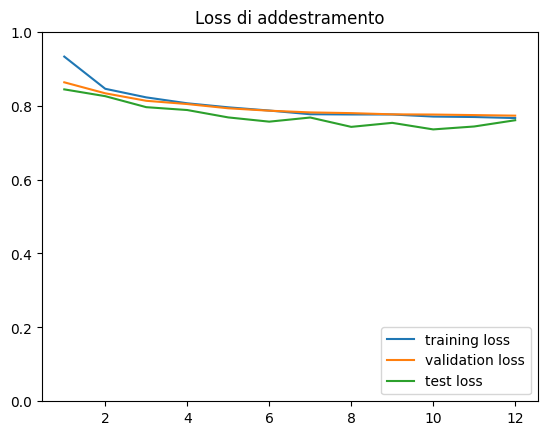

In [94]:
displayLosses(train_loss, test_loss, validation_loss)

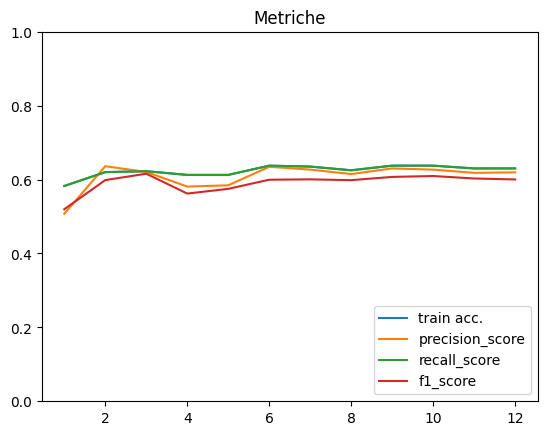

In [95]:
displayMetrics(accuracy, test_metrics)

In [96]:
(model, optimizer, checkpoint) = load_model("best_model.pth",
                                            model,
                                            opt,
                                            device)

In [97]:
test_loss, accuracy, epoch_metrics, y_true_nn, y_pred_nn, y_score_nn = eval_loop(model,
                                                                        test_loader,
                                                                        device)


In [98]:
from sklearn.metrics import confusion_matrix
conf = confusion_matrix(y_true_nn, y_pred_nn)

In [99]:
conf

array([[93,  7,  0,  0],
       [ 0, 51, 48,  1],
       [ 0,  9, 89,  2],
       [ 0, 14, 86,  0]])

In [100]:
cm

array([[  22,    0,    0],
       [1700,    7,    0],
       [1703,    0,    0],
       [1704,    0,    5]])

In [101]:
accuracy

0.5825

In [102]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_true_nn, y_score_nn, multi_class = "ovr", average = "macro")


np.float64(0.8244416666666667)

In [103]:
roc_auc_score(y_true_nn, y_score_nn, multi_class = "ovr", average = None)


array([0.9992    , 0.80163333, 0.78126667, 0.71566667])